# Fraud Detection



## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve


## 2. Load Dataset


In [15]:
df = pd.read_csv("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [16]:
print("Shape:", df.shape)
print(df["Class"].value_counts())
print((df["Class"].value_counts(normalize=True) * 100).round(4))


Shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


## 3. Class Imbalance

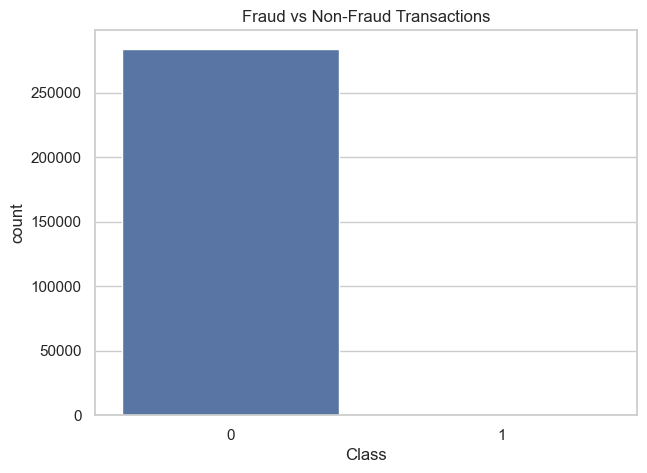

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Class")
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


## 4. Transaction Amount

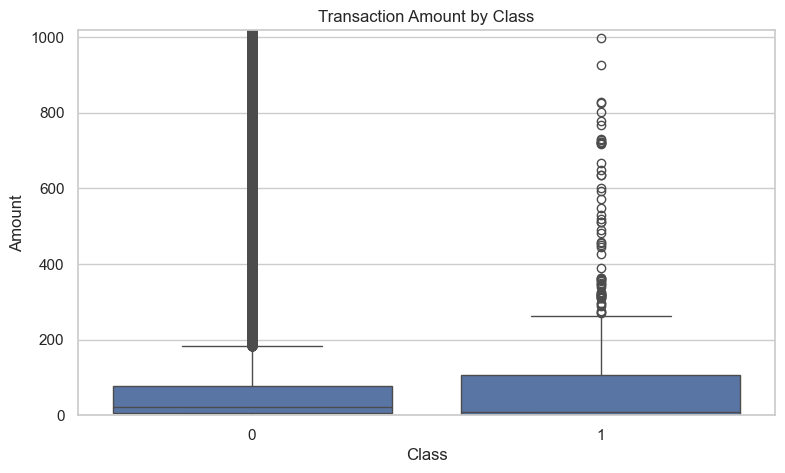

In [18]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Class", y="Amount")
plt.ylim(0, df["Amount"].quantile(0.99))
plt.title("Transaction Amount by Class")
plt.show()


## 5. Prepare Data

Accuracy alone is misleading because fraud transactions are rare. We use class weighting and evaluate precision, recall, F1, and ROC-AUC.

In [19]:
X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 6. Logistic Regression

In [20]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Precision: 0.060851926977687626
Recall: 0.9183673469387755
F1: 0.11414077362079898
ROC-AUC: 0.9721669425367221


## 7. Random Forest

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1: 0.8390804597701149
ROC-AUC: 0.9470530474429504


## 8. Confusion Matrices

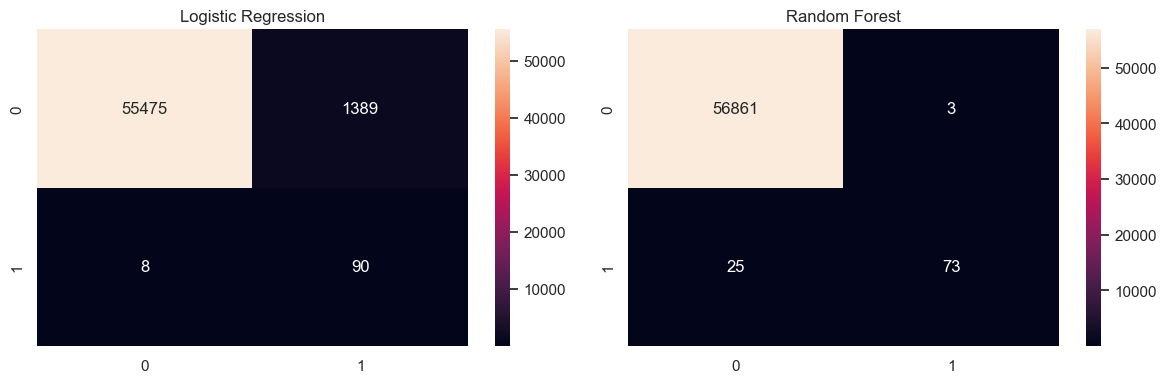

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


## 9. ROC Curve

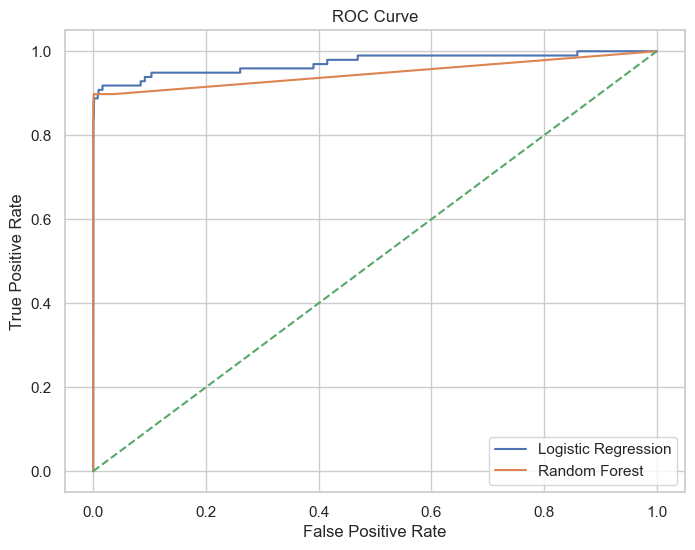

In [23]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 10. Model Comparison

In [25]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    "Recall": [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred)],
    "F1": [f1_score(y_test, lr_pred), f1_score(y_test, rf_pred)],
    "ROC-AUC": [roc_auc_score(y_test, lr_prob), roc_auc_score(y_test, rf_prob)]
})
comparison


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.060852,0.918367,0.114141,0.972167
1,Random Forest,0.960526,0.744898,0.839080,0.947053
